### Generate Predictions using Trained Models

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import sys
import os
import time
from pprint import pprint
sys.path.append(os.path.abspath(os.path.join('../diffusionsim')))
import xarray as xr
import matplotlib.pyplot as plt
import gcsfs
import json

import inspect
import dataclasses
import typing
import copy
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
#fs = gcsfs.GCSFileSystem()

In [2]:
import diffusers
import diffusionsim as diff
import diffusionsim.training_utils as tru
import diffusionsim.evaluations as evals
import diffusionsim.trainers as trainers
from diffusionsim import mydatasets as data

In [4]:
from ipywidgets import interact, widgets
from IPython.display import clear_output
%matplotlib inline

In [5]:
torch.cuda.is_available()
torch.set_grad_enabled(False); print("grad enabled: ", torch.is_grad_enabled())
device = 'cuda' if torch.cuda.is_available() else 'cpu'
exp_id = "diffusion_hp_search"
device

grad enabled:  False


'cuda'

In [6]:
run_id = "diff_1d_v1"
run = evals.Run(exp_id, run_id, climsim_run=False, cid='diff_1d_v1/best-')
rids = run.run_ids

In [7]:
trainer = run.reconstruct_trainer(apply_checkpoints=True, apply_indices=False)

ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


In [ ]:
run2d = self = evals.Run(exp_id, "lr-explore", climsim_run = False, cid='best')
trainer2d = run2d.reconstruct_trainer(apply_checkpoints=True, apply_indices=False)

In [8]:
print(run.logs.keys())
print(run.logs[rids[0]].keys())

dict_keys(['data_config', 'diff_1d_v1a', 'diff_1d_v1b', 'diff_1d_v1c', 'diff_1d_v1d'])
dict_keys(['training_config', 'model_config', 'losses', 'gradients', 'nan_incidents'])


In [9]:
def plot_sampled_timesteps(run):
    fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(8, 15), sharex=True)

    for i in range(len(run.run_ids)):
        density = run.get('sampled_timesteps', i) / np.sum(run.get('sampled_timesteps', i))
        axes[i].plot(density, label=run.run_ids[i])
        axes[i].legend()

    plt.tight_layout()
    plt.show()

In [10]:
dl = trainer.dataloaders['train']
ds = dataset = train_ds = dl.dataset
ds.log = False
type(ds)

diffusionsim.mydatasets.ClimsimDataset

In [11]:
# generate images
from collections import defaultdict
class SampleImages(torch.utils.data.IterableDataset):
    def __init__(self, ddpm, scheduler, steps=100, batch_size=1, eta=1.0):
        self.ddpm = ddpm.to(device)
        self.scheduler = scheduler
        self.set_num_images(batch_size)
        self.eta = 1.0
        # generator: Optional[Union[torch.Generator, List[torch.Generator]]] = None
        # A [`torch.Generator`](https://pytorch.org/docs/stable/generated/torch.Generator.html) make
        # generation deterministic.
        self.num_inference_steps = steps
        
    def set_num_images(self, batch_size):
        self.batch_size = batch_size
        self.image_shape = (batch_size, self.ddpm.config.in_channels, *self.ddpm.config.sample_size)

    def __iter__(self):
        # generate a batch of images
        pipeline = diffusers.DDIMPipeline(self.ddpm, self.scheduler)
        self.scheduler.set_timesteps(self.num_inference_steps)
        while(True): # can generate infinite batches      
            image = torch.randn(self.image_shape ).to(device) # could add generator=generator
            for t in pipeline.progress_bar(self.scheduler.timesteps):
                image = self._denoise(image, t)
            yield image
    
    def _denoise(self, xt, t):
        eps_theta = self.ddpm(xt, t).sample
        x_prev = self.scheduler.step(eps_theta, t, xt, eta=self.eta)
        prev_timestep = t - self.scheduler.config.num_train_timesteps // self.scheduler.num_inference_steps
        return(x_prev.prev_sample, prev_timestep)
        
    def encode(self, sample, t, eps=None):
        if eps is None:
            eps = torch.randn(sample.shape, device=device) # BS x C x H x W
        xt = self.scheduler.add_noise(sample, eps, torch.LongTensor([t])) # noisy image
        return(xt, eps)
    
    def decode(self, xt, T, stride=1, track_history=True):
        stride = abs(stride)
        self.scheduler.set_timesteps(self.scheduler.config.num_train_timesteps//stride)
        if track_history:
            history={}
        pipeline = diffusers.DDIMPipeline(self.ddpm, self.scheduler)
        for i in pipeline.progress_bar(range(T, -1, -stride)): # pipe.scheduler.timesteps[-T//stride-1:]
            if track_history:
                history[T] = xt.detach().cpu()
            xt, T = self._denoise(xt, T)
        if track_history:
            return(history)
        return(xt)

    def encode_decode(self, x0, T, stride=1, timestep_funcs={}):
        func_results = defaultdict(list)
        stride = abs(stride)
        self.scheduler.set_timesteps(self.scheduler.config.num_train_timesteps//stride)
        pipeline = diffusers.DDIMPipeline(self.ddpm, self.scheduler)
        for t in range(0, T, stride):
            func_results["T"].append(t)
            xt, eps = self.encode(x0, t)
            func_results["xt"].append(xt.detach().cpu().clone())
            for func_name, func in timestep_funcs.items():
                func_results[func_name].append(func(xt, x0))
        while(t > 0):
            xt, t = self._denoise(xt, t)
            func_results["T"].append(t)
            func_results["xt"].append(xt.detach().cpu().clone())
            for func_name, func in timestep_funcs.items():
                func_results[func_name].append(func(xt, x0))
        return(func_results)

In [35]:
ddpm = run.get_model(0)
ddpm.device, type(ddpm.model)

mconfig = run.get_mconfig(0)
mconfig.scheduler_type = 'ddim'

scheduler = data.load_scheduler(mconfig)
scheduler.config.timestep_spacing = "linspace"

In [ ]:
#trainer = tru.setup_trainer(exp_id, run_id, tconfig, mconfig, dconfig)
#trainer.dataloaders['train'].dataset.log = False

run2d.get_mconfig(0).scheduler_type  = 'ddim'
scheduler = data.load_scheduler(run2d.get_mconfig(0))
scheduler.config.timestep_spacing = "linspace"

ddpm2d = run2d.get_model(0)
ddpm2d.device, type(ddpm1d.model)

(device(type='cuda', index=0), diffusionsim.models.ClimsimUNet1DModel)

### Generating Data

In [13]:
num_images = 100

In [14]:
indices = np.random.randint(0, ds.dso.time.size, size=num_images)
x_og = ds.dsi.isel(time=indices).load()
y_og = ds.dso.isel(time=indices).load()

In [ ]:
def make_tendencies(x, y, dutils):
    vars = ['state_t', 'state_q0001']
    if dutils.full_vars:
        vars += ['state_q0002', 'state_q0003', 'state_u', 'state_v']
    for v in vars:
        y[v.replace('state', 'ptend')] = (y[v] - x[v]) / 1200
    return(y[dutils.target_vars_tendencies])

def create_sample(x=None, y=None, ds=None):
    y = copy.deepcopy(y)
    # mimics get_item from loaded xarray subsample
    if ds.dutils.use_tendencies:
        assert x is not None, "x is required for tendencies"
        y = make_tendencies(x, y, ds.dutils)
        x, y = ds.normalize(y, y)
    else:
        if x is not None:
            x, y = ds.normalize(x, y)
        else:
            y = (y - ds.ym) / ds.ys
    return(ds._make_image(y, "mlo"))

def recreate_sample(sample, dataset):
    # TODO : Fix this
    if(isinstance(sample, torch.Tensor)):
        if(sample.device != 'cpu'):
            sample = sample.detach().cpu()
        sample = sample.numpy()
    
    xarr = xr.DataArray(sample.reshape(-1, 128, 384), dims="time mlo ncol".split(), coords=dict(
        time = np.arange(sample.shape[0]),
        mlo = dataset.mlo, 
        ncol = dataset.permute_indices
    )).isel(ncol=np.argsort(dataset.permute_indices))
    return xarr
    if "ncol" in dataset.Ymean.dims:
        mu_stack = dataset.Ymean.to_stacked_array(new_dim="mlo", sample_dims=('ncol',))
        sig_stack = dataset.Ystd.to_stacked_array(new_dim="mlo", sample_dims=('ncol',))
        xrec = (xarr * sig_stack.mean(dim='ncol')) + mu_stack.mean(dim='ncol')
    else:
        mu_stack = dataset.Ymean.to_stacked_array(new_dim="mlo", sample_dims=())
        sig_stack = dataset.Ystd.to_stacked_array(new_dim="mlo", sample_dims=())
        xrec = (xarr * sig_stack) + mu_stack
    
    return(xrec.transpose("time", "ncol", "mlo"))

In [17]:
ds.image_dim = None
y_sample = create_sample(x_og, y_og, ds)
ds.image_dim = 1
y_1d = create_sample(x_og, y_og, ds)
ds.image_dim = 2
y_2d = create_sample(x_og, y_og, ds)
y_sample.shape, y_1d.shape, y_2d.shape

(torch.Size([38400, 128]),
 torch.Size([38400, 10, 64]),
 torch.Size([100, 128, 16, 24]))

In [36]:
pipeline = diffusers.DDIMPipeline(ddpm, scheduler)
pipeline_generator = SampleImages(ddpm, scheduler)

### Loading Mean Data for Comparison

In [63]:
dutils = ds.dutils
X_mean, X_std, Y_mean, Y_std = diff.climsim_utils.get_norm_info(style='image', sanitize=False)

In [64]:
X_mean_img = X_mean[ds.dutils.input_vars].isel(ncol=dutils.permute_indices).to_stacked_array(new_dim="mlx", sample_dims=("ncol",))
X_mean_img = X_mean_img.data.reshape(16, 24, -1).transpose((2, 0, 1))

X_std_img = X_std[ds.dutils.input_vars].isel(ncol=dutils.permute_indices).to_stacked_array(new_dim="mlx", sample_dims=("ncol",))
X_std_img = X_std_img.data.reshape(16, 24, -1).transpose((2, 0, 1))

Y_mean_img = Y_mean[ds.dutils.target_vars].isel(ncol=dutils.permute_indices).to_stacked_array(new_dim="mlx", sample_dims=("ncol",))
Y_mean_img = Y_mean_img.data.reshape(16, 24, -1).transpose((2, 0, 1))

Y_std_img = Y_std[ds.dutils.target_vars].isel(ncol=dutils.permute_indices).to_stacked_array(new_dim="mlx", sample_dims=("ncol",))
Y_std_img = Y_std_img.data.reshape(16, 24, -1).transpose((2, 0, 1))

X_mean_img.shape

(124, 16, 24)

## Looking at trained model weights

In [ ]:
for run_id in run.run_ids:
    print(f"___________\nModel {run_id}\n___________")
    model = run.get_model(run_id)

    for name, param in model.named_parameters():
        print(name, "                 ", torch.mean(param))
    

In [ ]:
weights = torch.load(ckpt, map_location=trainer.device)

In [ ]:
import re
for name, param in trainer.models['lr-explorea'].named_parameters():
    if re.search(r'\.norm\d+\.(weight|bias)', name):
        print(name, "                 ", torch.mean(param).item())
    elif 'time_embedding' in name:
        pass
    elif 'conv' in name:
        pass

    elif re.search(r'\.weight|\.bias', name):
       pass 
    else:
        print("wahuhhh")

In [ ]:
trainer.models.keys()

In [ ]:
ckpt = "/mnt/home/ssa2206/Climsim/experiments/diffusion_hp_search/checkpoints/lr-searcha-ckpt.pt"
weights = torch.load(ckpt, map_location=trainer.device)


In [ ]:
import re
noise_levels = [0.0, 0.5, 1.0, 1.0, 1.5]
for i, run_id in enumerate(trainer.models.keys()):
    model = trainer.models[run_id]
    model.load_state_dict(weights)
    noise_level = noise_levels[i]

    for name, param in model.named_parameters():
        if not param.requires_grad or re.search(r'\.norm\d+\.(weight|bias)', name):
            continue
        with torch.no_grad():
            std = torch.std(param).item()
            #mean = torch.mean(param).item()
            if 'time_embedding' in name:
                param.add_(0.3 * noise_level * std * torch.randn_like(param))
            elif 'conv' in name:
                param.add_(0.05 * noise_level * std * torch.randn_like(param))
            elif re.search(r'\.weight|\.bias', name):
                param.add_(0.5 * noise_level * std * torch.randn_like(param))
            else:
                print(f"  -> Skipping: {name}")


## Testing Sample Recreation

In [ ]:
pipeline_generator = SampleImages(run.get_model(0), scheduler)

In [ ]:
pipeline_generator.set_num_images(64)
gen_images = next(iter(pipeline_generator)).detach().cpu()

In [ ]:
real_images = dataset[0].detach().cpu()

In [ ]:
real_images.shape, gen_images.shape

In [ ]:
evals.hist(gen_images.flatten(), title='Diffusion Generated Images')

In [ ]:
plt.hist(real_images.numpy().flatten()) # more variance/ tails 
plt.show()

In [ ]:
avg_diffusion_image = torch.mean(gen_images, dim=0)
avg_diffusion_image.shape

In [ ]:
def mean_image(img):
    img = img.detach().cpu()
    def plot_image(i):
        plt.imshow(img[i].numpy())
        plt.title(f"Image Var: {i}")
        plt.axis('off')
        plt.show()

    # Interactive slider: i ranges from 0 to img.shape[0] - 1
    interact(plot_image, i=(0, img.shape[0] - 1))



In [ ]:
real_images.mean(dim=[0,2,3]).detach().cpu() - gen_images.mean(dim=[0,2,3]).detach().cpu()

In [ ]:
sample = tru.recreate_sample(gen_images, ds)
sample

In [ ]:
rec_image_real = tru.recreate_sample(real_images, ds)
rec_image_gen = tru.recreate_sample(gen_images, ds)
tmap = rec_image_gen.isel(time=0, mlo=59, ncol=dataset.permute_indices).data
plt.imshow(tmap.reshape(16, 24), cmap='plasma')
plt.colorbar()
plt.show()

In [ ]:
tmap = rec_image_real.isel(time=0, mlo=59, ncol=dataset.permute_indices).data
plt.imshow(tmap.reshape(16, 24), cmap='plasma')
plt.colorbar()
plt.show()

In [ ]:
og = dataset.data.state_t.isel(time=0, lev=59, ncol=dataset.permute_indices).load().data
print(np.isclose(tmap, og).all()) # same
(tmap - og).max()

In [ ]:
ds0 = dataset.bgen[0].load()
ds0 = ds0.to_stacked_array(new_dim='mlo', sample_dims=("time", "ncol"))
np.isclose(rec_image_real, ds0, atol=5e-5).all()

In [ ]:
original_stderr_write = sys.stderr.write
# Define a custom stderr.write that filters out the OpenBLAS warning
def suppressed_stderr_write(message, omit='OpenBlas'):
    original_stderr_write = sys.stderr.write    
    if omit not in message:
        original_stderr_write(message)

sys.stderr.write = suppressed_stderr_write

#### testing pipeline speed

In [ ]:
gen = torch.Generator()
gen

In [ ]:
#os.environ['OPENBLAS_VERBOSE'] = '0'
#import warnings
#warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
import time
pipeline_test = dict(sizes=[1, 2, 4, 8, 16, 32, 64, 128, 256], times=[], batches=[], device=device)

for sz in pipeline_test['sizes']:
    print(f"generating {sz} images from pipeline")
    now = time.time()
    images = pipeline(eta=0, batch_size=sz, generator=gen, num_inference_steps=50, output_type='numpy').images
    pipeline_test['times'].append(time.time() - now)
    pipeline_test['batches'].append(images)

In [ ]:
m, b = np.polyfit(pipeline_test['sizes'][:len(pipeline_test['times'])], pipeline_test['times'], 1)
slope = np.dot(pipeline_test['sizes'][:len(pipeline_test['times'])], pipeline_test['times']) / np.dot(pipeline_test['sizes'], pipeline_test['sizes'])

plt.scatter(pipeline_test['sizes'][:len(pipeline_test['times'])], pipeline_test['times'])
plt.plot(pipeline_test['sizes'][:len(pipeline_test['times'])], np.array(pipeline_test['sizes'][:len(pipeline_test['times'])]) * slope)


seems like batch size does not really matter for generation speed- seconds/sample stays the same. 

In [ ]:
plt.hist(np.array(pipeline_test['batches'][-1]).flatten())

In [ ]:
images = np.transpose(images, (0, 3, 1, 2))
images.shape

In [ ]:
plt.imshow(images[0, 59])

### Comparing empirical dataset norms to saved

In [ ]:
from climsim_data_utils import data_utils, load_vars

In [ ]:
mapper = fs.get_mapper("gs://leap-persistent-ro/sungdukyu/E3SM-MMF_ne4.grid-info.zarr")
grid_info = xr.open_dataset(mapper, engine='zarr')

dutils = data_utils(grid_info=grid_info)

In [ ]:
def reconstruct_np(X_norm, Y_norm, data_vars='v1'):
    inputs, outputs = load_vars(data_vars)
    input_mean = xr.open_dataset('Climsim_info/input_mean.nc')[inputs].to_stacked_array('mlvar', sample_dims='').values
    input_max = xr.open_dataset('Climsim_info/input_max.nc')[inputs].to_stacked_array('mlvar', sample_dims='').values
    input_min = xr.open_dataset('Climsim_info/input_min.nc')[inputs].to_stacked_array('mlvar', sample_dims='').values
    output_scale = xr.open_dataset('Climsim_info/output_scale.nc')[inputs].to_stacked_array('mlvar', sample_dims='').values

    X = X_norm*(input_max - input_min) + input_mean
    Y = Y_norm / output_scale
    return(X,Y)

In [ ]:
x_avg = x_npy.mean(axis=0)
x_avg.shape

In [ ]:
x_norm = xr.open_dataset("Climsim_info/input_mean.nc")

In [ ]:
x_norm_v1 = x_norm[dutils.v1_inputs].to_stacked_array('mlvar', sample_dims='').values

In [ ]:
(x_avg -x_norm_v1)

In [ ]:
plt.scatter(np.arange(60), x_norm_v1[:60])
plt.scatter(np.arange(60), x_avg[:60])

In [ ]:
output_scaling = xr.open_dataset("Climsim_info/output_scale.nc")

oscaling  = output_scaling[dutils.v1_outputs].to_stacked_array('mlvar', sample_dims='').values

In [ ]:
y_avg = y_npy.mean(axis=0)
y_scale_test = 1./ y_avg

In [ ]:
y_avg

In [ ]:
y_scale_test

In [ ]:
plt.plot(np.arange(60), oscaling[60:120])
#plt.plot(np.arange(60), y_scale_test[60:120])

In [ ]:
oscaling.values()

# Image Metrics

In [ ]:
pipeline_generator.set_num_images(32)
dimages = next(iter(pipeline_generator))

In [ ]:
images = train_ds[0]

In [ ]:
images.shape

### SSIM

In [ ]:
from torchmetrics.image import StructuralSimilarityIndexMeasure as SSIM

In [ ]:
ssim = SSIM(data_range=1.0).to(device)

In [ ]:
sssim = SSIM(data_range=1.0)

In [ ]:
%%time
sssim(images, dimages.detach().cpu())

In [ ]:
dimages.device

In [ ]:
device

In [ ]:
%%time
ssim(images.to(device), dimages)

## Spectral

In [ ]:
dim_ftt = torch.fft.fft(dimages)

In [ ]:
dim_ftt.shape, dimages.shape

mag, phase = torch.abs(dim_ftt), torch.angle(dim_ftt) 

In [ ]:
plt.imshow(mag[0][59].detach().cpu().numpy())
plt.colorbar()
plt.show()

In [ ]:
plt.imshow(phase[0][59].detach().cpu().numpy())
plt.colorbar()
plt.show()

# Evaluating

Ok so we have a diffusion model... is it any good?

[Check Pipeline Source Code](https://github.com/huggingface/diffusers/blob/main/src/diffusers/pipelines/ddim/pipeline_ddim.py)

### Test 0: Inspecting Generated Images

In [ ]:
dsi, dso = diff.climsim_utils.load_raw_dataset(run.dconfig)
dso.sizes

In [ ]:
plt.hist(real_images.flatten())

In [ ]:
pipeline_generator.set_num_images(100)
gen = iter(pipeline_generator)
gen_images = next(gen).detach().cpu()

In [ ]:
real_images.shape, gen_images.shape

In [ ]:
rec_images_gen = tru.recreate_sample(gen_images, ds)
rec_images = tru.recreate_sample(real_images, ds)

In [ ]:


def interactive_image_viewer(images, cmap='viridis', dataset=train_ds):
    """
    Interactive viewer to display a 2D slice from a 4D array of images.
    
    Parameters:
    images (np.ndarray): A numpy array of shape (100, 128, 16, 24), representing 100 sets of maps,
                         each containing 128 variables, each of size 16x24.
    """
    # Define interactive plot function
    def plot_image(index, variable):
        vmap = images.isel(time=index, mlo=variable, ncol=dataset.permute_indices).data
        plt.imshow(vmap.reshape(16,24), cmap=cmap)
        plt.colorbar()
        plt.title(f"Image {index + 1} - Variable {dataset.mlo[variable].item()}")
        plt.axis("off")
        plt.show()

    # Create interactive widgets
    n, d = images.time.size, images.mlo.size
    index_slider = widgets.IntSlider(value=0, min=0, max=n-1, step=1, description='Index:')
    variable_slider = widgets.IntSlider(value=0, min=0, max=d-1, step=1, description='Variable:')
    
    # Display interactive plot
    interact(plot_image, index=index_slider, variable=variable_slider)

# Example usage:
# images = np.random.rand(100, 128, 16, 24) # Replace with your actual data
interactive_image_viewer(rec_images)

### Test One: Using DDPM as Encoder-Decoder
Let's imagine $x_{in} \in \mathbb{R}^{C \times H \times W}$ is the output of your ML emulator. I want to perturb $x$ to a noisy sample $z_t$; the larger the t, the further away I am taking from the image manifold before denoising back. 



Encoding: Noising a sample $$x_t(x_0, \epsilon) = \sqrt{\bar{\alpha_t}} \cdot x_0 + \sqrt{1-\bar{\alpha_t}} \cdot \epsilon$$

Decoding: De-Noising it and bring it closer to distribution
$$\epsilon_{\theta} = DDPM(z_t, t)$$
$$x_{t-1} \sim p_{\theta}(x_{t-1}|x_t) = \dfrac{1}{\sqrt{\alpha_t}}\left( x_t - \dfrac{\beta_t}{\sqrt{1-\bar{\alpha_t}}}\epsilon_{\theta}\right) + \sigma_t z, z\sim \mathcal{N}(0, 1)$$


In [37]:
image_dim = 1

In [20]:
def plot_profile(data, var_index=None, ax=None, title='', **kwargs):
    data = np.asarray(data)
    assert data.ndim < 4, "no more than 3d"
    if data.ndim == 3:
        assert var_index is not None, "need to specify variable"
        data = data[:, var_index, :]
    elif(data.ndim == 2 and data.shape[0] == 10):
        data = data[var_index]
    levels = np.arange(data.shape[-1])
    if ax is None:
        fig, ax = plt.subplots()
    if data.ndim == 1:
        im = ax.plot(data, levels, **kwargs)
    else:
        for profile in data: 
            im = ax.plot(profile, levels, **kwargs) 
    ax.invert_yaxis()
    ax.set_ylabel("Level index (0 = top)")
    ax.set_title(title)
    if var_index is not None: 
        ax.set_xlabel(ds.target_vars[var_index])
    return(im)

y_1d.shape

torch.Size([38400, 10, 64])

In [60]:
T = 20
if image_dim == 1:
    x_noisy, eps = pipeline_generator.encode(y_1d.to(device), T)
elif image_dim == 2:
    x_noisy, eps = pipeline_generator.encode(y_2d.to(device), T)

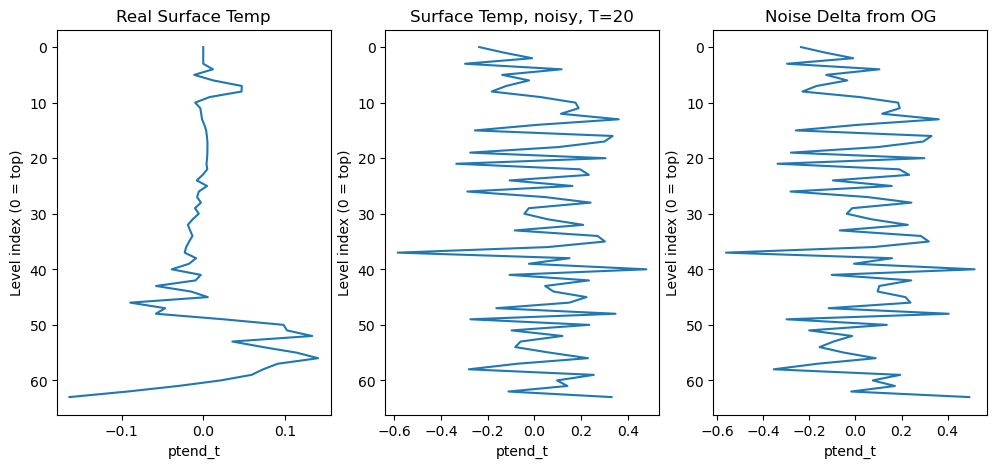

In [61]:
x_noisy = x_noisy.detach().cpu()
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

if image_dim == 1:
    im0 = plot_profile(y_1d[0], var_index=0, ax=axes[0], title="Real Surface Temp")
    im1 = plot_profile(x_noisy[0], var_index=0, ax=axes[1], title="Surface Temp, noisy, T=" + str(T))
    im2 = plot_profile((x_noisy[0] - y_1d[0]), var_index=0, ax=axes[2], title="Noise Delta from OG")
elif image_dim == 2: 

    im0 = axes[0].imshow(y_2d[0, 59])
    axes[0].set_title("Real Surface Temp")
    fig.colorbar(im0, ax=axes[0])
    im1 = axes[1].imshow(x_noisy[0, 59])
    axes[1].set_title("Surface Temp, noisy, T=" + str(T))
    fig.colorbar(im1, ax=axes[0])
    im2 = axes[2].imshow((x_noisy - y_2d)[0, 59])
    axes[2].set_title("Noise Delta from OG")
    fig.colorbar(im2, ax=axes[2])

plt.show()

In [62]:
denoising_history = pipeline_generator.decode(x_noisy.to(device), T, stride=T//10)

  0%|          | 0/11 [00:00<?, ?it/s]

In [63]:

denoising_history[16].shape

torch.Size([38400, 10, 64])

In [64]:
def plot_histogram_evolution(history):
    def plot_timestep(t):
        plt.figure(figsize=(10, 6))
        plt.hist(history[t].flatten(), bins=50, density=True)
        plt.title(f'Distribution at Denoising Step {t}')
        plt.xlabel('Values')
        plt.ylabel('Density')
        plt.grid(True)
    
    # Create slider for time steps
    steps = sorted(history.keys(), reverse=False)
    t_slider = widgets.SelectionSlider(options=steps, value=steps[-1], description='Time Step:', continuous_update=False,)
    
    # Display interactive plot
    interact(plot_timestep, t=t_slider)

plot_histogram_evolution(denoising_history)

interactive(children=(SelectionSlider(continuous_update=False, description='Time Step:', index=10, options=(0,…

In [70]:
history[6].device, history[6].shape

(device(type='cpu'), torch.Size([100, 128, 16, 24]))

In [74]:
def denoising_history(history, cmap='plasma', dataset=ds):
    # Define interactive plot function
    def plot_image(index, variable, denoise_step):
        plt.close('all')
        clear_output(wait=True)
        vmap = recreate_sample(history[denoise_step], ds).isel(time=index, mlo=variable, ncol=dataset.permute_indices).data
        plt.imshow(vmap.reshape(16,24), cmap=cmap)
        plt.colorbar()
        plt.title(f"Image {index + 1} - Variable {dataset.mlo[variable].item()}")
        plt.axis("off")
        plt.show()

    # Create interactive widgets
    n, d = history[0].shape[:2]
    index_slider = widgets.IntSlider(value=0, min=0, max=n-1, step=1, description='Index:')
    variable_slider = widgets.IntSlider(value=0, min=0, max=d-1, step=1, description='Variable:')
    steps = sorted(history.keys())
    noise_slider = widgets.SelectionSlider(options=steps, value=steps[-1], description='Time Step:', continuous_update=False,)
    # Display interactive plot
    interact(plot_image, index=index_slider, variable=variable_slider, denoise_step=noise_slider)


In [65]:
denoising_history(history)

TypeError: 'dict' object is not callable

In [66]:
pure_noise = False

if pure_noise:
    x0 = torch.randn(real_images.shape, device=device)
else:
    x0 = [None, y_1d, y_2d][image_dim].to(device)

x0.shape

torch.Size([38400, 10, 64])

In [67]:
eps.shape

torch.Size([38400, 10, 64])

In [73]:
noising_history = {}
for t in range(0, T, T//10):
    nxt, eps = pipeline_generator.encode(x0, t, eps)
    noising_history[t] = nxt.detach().cpu()

In [74]:
history = dict(noising=noising_history, denoising=denoising_history)



In [75]:
history.keys(), history['noising'].keys(), history['denoising'].keys()

(dict_keys(['noising', 'denoising']),
 dict_keys([0, 2, 4, 6, 8, 10, 12, 14, 16, 18]),
 dict_keys([20, 18, 16, 14, 12, 10, 8, 6, 4, 2, 0]))

In [93]:
def calc_metrics(history, metrics_dict):
    x0 = history['noising'][0]
    retval = {"T" : []}
    for metric_name, metric_func in metrics_dict.items():
        for t, xt in history['noising'].items():
            retval["T"].append(t)
            retval.setdefault(metric_name, []).append(metric_func(xt, x0))
        for t, xt in history['denoising'].items():
            retval["T"].append(t)
            retval.setdefault(metric_name, []).append(metric_func(xt, x0))
    return(retval)

In [81]:
dist = torch.nn.MSELoss()

metrics_dict = {
    'deviation_from_mean': lambda xt, x0: dist(xt, torch.zeros_like(xt)).item(),
    'x0_dist': lambda xt, x0: dist(xt, x0).item()
}

metrics = calc_metrics(history, metrics_dict)

range(0, 21, 2)


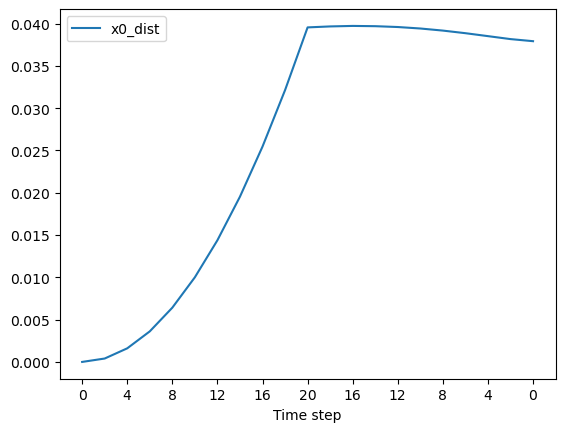

In [85]:
def plot_metric(metrics_dict, metric):
    x = range(len(metrics_dict[metric]))
    plt.plot(x, metrics_dict[metric], label=metric)
    plt.xlabel("Time step")
    t_int = x[::max(len(x)//10,1)]
    print(t_int)
    plt.xticks(ticks=t_int, labels=[metrics_dict["T"][i] for i in t_int])
    plt.legend()
    plt.show()

plot_metric(metrics, "x0_dist")

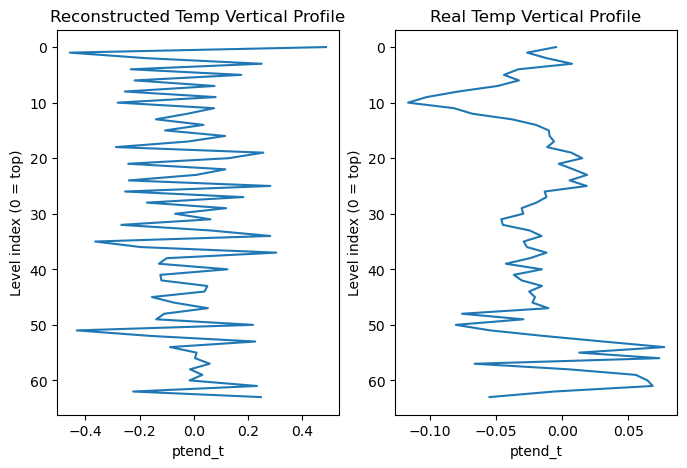

In [92]:

sample_index = 89

fig, axes = plt.subplots(1, 2, figsize=(8, 5))
plot_profile(history['denoising'][0][sample_index], var_index=0, ax=axes[0], title="Reconstructed Temp Vertical Profile")
plot_profile(history['noising'][0][sample_index], var_index=0, ax=axes[1], title="Real Temp Vertical Profile")

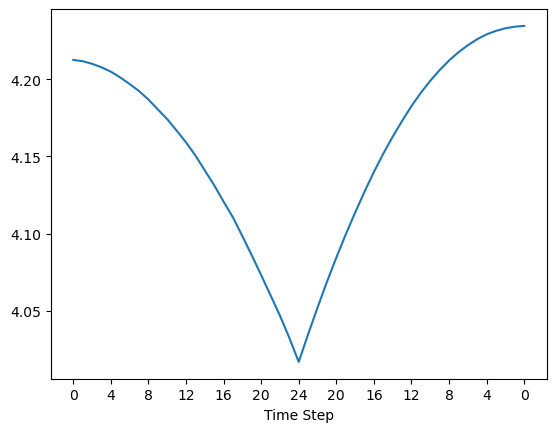

In [88]:
labels = res["T"]
x = range(len(labels))  # index positions

plt.plot(x, res['mean_dist'])
plt.xlabel("Time Step")
plt.xticks(ticks=x[::max(len(x)//10,1)], labels=[labels[i] for i in x[::max(len(x)//10,1)]])
plt.show()

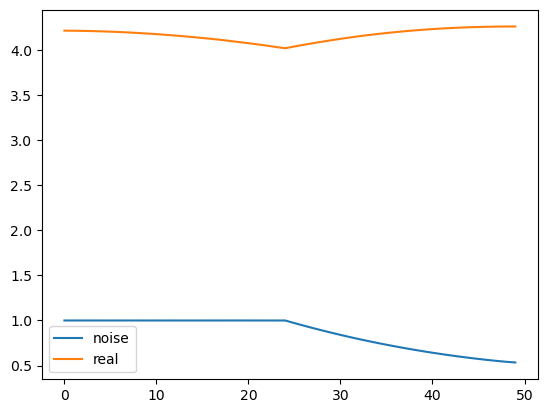

In [87]:
plt.plot(mu_dist, label="noise")
plt.plot(mu_dist_real, label="real")
plt.legend()
plt.show()

In [ ]:
print(len(ds))
num_batches = 5
indices = torch.randint(0, len(ds), (num_batches,))
indices

In [174]:
Ts = [10, 25, 40]
data = {}
x0 = real_images.to(device)
for T in Ts:
    res_t = pipeline_generator.encode_decode(x0, T, timestep_funcs={"mean_dist": mean_dist, "x0_deviation_dist": x0_deviation_dist})
    data[T] = res_t

In [177]:
data[10].keys()

dict_keys(['T', 'xt', 'mean_dist', 'x0_deviation_dist'])

In [ ]:
data[10]

labels = res["T"]
x = range(len(labels))  # index positions

plt.plot(x, res['mean_dist'])
plt.xlabel("Time Step")
plt.xticks(ticks=x[::max(len(x)//10,1)], labels=[labels[i] for i in x[::max(len(x)//10,1)]])
plt.show()

dict_keys([10, 25, 40])

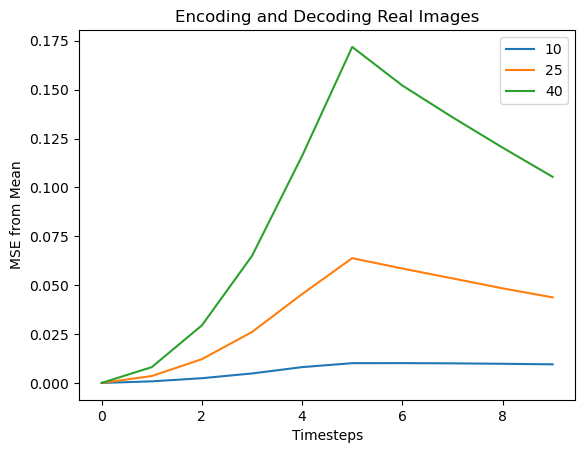

In [179]:
plt.plot(data[10]['x0_deviation_dist'][::2], label=10)
plt.plot(data[25]['x0_deviation_dist'][::5], label=25)
plt.plot(data[40]['x0_deviation_dist'][::8], label=40)
plt.legend()
plt.title(f"Encoding and Decoding Real Images")
plt.ylabel("MSE from Mean")
plt.xlabel("Timesteps")
plt.show()

In [77]:
plt.plot(data[10], label=10)

TypeError: 'module' object is not subscriptable

In [ ]:
Ts = [10, 25, 50]
data = {}
for T in Ts:
    data[T] = encode_decode_dists(ds, int(indices[0]), T, pure_noise=True, verbose=True)
    for index in indices[1:]:
        data[T] += encode_decode_dists(ds, int(index), T, pure_noise=True, verbose=True)

In [ ]:
plt.plot(data[10][::2], label=10)
plt.plot(data[25][::5], label=25)
plt.plot(data[50][::10], label=50)
plt.legend()
plt.title(f"Encoding and Decoding Pure Noise")
plt.ylabel("MSE from Original Data")
plt.xlabel("Timesteps")
plt.show()

In [ ]:
Ts = [10, 25, 50]
data = {}
for T in Ts:
    data[T] = encode_decode_dists(train_ds, int(indices[0]), T, verbose=True)
    for index in indices[1:]:
        data[T] += encode_decode_dists(train_ds, int(index), T, verbose=True)

In [ ]:
for key, value in data.items():
    data[key] = value / len(indices)

In [ ]:
data[10]

In [ ]:
plt.plot(data[10][::2], label=10)
plt.plot(data[25][::5], label=25)
plt.plot(data[50][::10], label=50)
plt.legend()
plt.title(f"Encoding and Decoding data at different noise levels, averaged across {len(indices)} random items")
plt.ylabel("MSE from Original Data")
plt.xlabel("Timesteps")
plt.show()

In [ ]:
for key, value in data.items():
    data[key] = list(value)

In [ ]:
with open("images/ED_difftest.json", 'w') as file:
    json.dump(data, file)

In [ ]:
data[25]

In [ ]:
for t in data.keys():
    plt.plot(data[t], label=f'Noised to step {t}')

plt.legend()
plt.show()

In [ ]:
encode_decode_dists(train_ds, 64, 99, verbose=True)

In [ ]:
for t in [99]:
    print("At time ", t)
    distances = 0
    for index in torch.randint(0, len(train_ds), (num_batches,)).numpy():
        print(index, end=" ")
        distances = distances + encode_decode_dists(train_ds, int(index), t)

    data[t] = distances / num_batches



In [ ]:
ds = encode_decode_dists(train_ds, 83, 25)

In [ ]:
plt.plot(ds)

In [ ]:
%%time
item = train_ds[26]

In [ ]:
item.shape

In [ ]:
x25, eps = encode(item.to(device), 25)

In [ ]:
x0_hat, history25 = decode(x25, 25)

In [ ]:
dist = torch.nn.MSELoss()
history25['diffs'] = []
for t in list(history25.keys()):
    if isinstance(t, int):
        history25['diffs'].append(dist(item.to(device), history25[t]).item())

In [ ]:
#plt.plot(history['diffs'])
plt.plot(history25['diffs'])

#### How it works

In [ ]:
t = 25

In [ ]:
zt, eps = encode(item, 25)

In [ ]:
zt.shape

In [ ]:
at = scheduler.alphas_cumprod[t]
zt_manual = torch.sqrt(at) * item + torch.sqrt(1-at)*eps

(zt_manual == zt).all().item()

In [ ]:
with torch.no_grad():
    eps_theta = ddpm(zt.to(device), torch.tensor([25], device=device))

In [ ]:
x24 = ddim_scheduler.step(eps_theta.sample, 25, zt.to(device)).prev_sample

In [ ]:
x24.shape

In [ ]:
a24 = ddim_scheduler.alphas_cumprod[24]
a25 = ddim_scheduler.alphas_cumprod[25]

DDIM Sampling:
$$x_{t-1} = \sqrt{\alpha_{t-1}}\left( \dfrac{x_t - \sqrt{1-\alpha_t} \epsilon_\theta}{\sqrt{\alpha_t}}\right) + \sqrt{1-\alpha_{t-1}} \cdot \epsilon_\theta$$

If taking larger strides, can replace $\alpha_{t-1}$ with $\alpha_{t-n}$

In [ ]:
x24_manual = (zt.to(device) - torch.sqrt(1 - a25) * eps_theta.sample) / torch.sqrt(a25)
x24_manual = torch.sqrt(a24) * x24_manual + torch.sqrt(1 - a24) * eps_theta.sample

In [ ]:
(x24 == x24_manual).all().item()

In [ ]:
scheduler.set_timesteps(50)
print(scheduler.timesteps) # x_t-1 becomes x80 | x90
print(scheduler.config.num_train_timesteps, scheduler.num_inference_steps)
scheduler.set_timesteps(100)

In [ ]:
T, stride = 20, 2
scheduler.set_timesteps(scheduler.config.num_train_timesteps // stride)
scheduler.timesteps[-T//stride-1:]

In [ ]:
plt.hist(denoised_image.flatten()) # x0_reconstructed

In [ ]:
plt.hist(train_ds[0].flatten())

## Distribution Metrics

Series of evaluation metrics between two datasets $\mathcal S_r$ (training corpus) and $\mathcal S_f$ (generated images) respectively. Idea is to use N samples from each learned distribution and rate model on some kind of distribution distance metric. 

In [ ]:
vae_exp_id = "VAE_August05_08:23"
vae_log_pth = "trial_log.json"
with open(os.path.join("experiments", vae_exp_id, vae_log_pth), 'r') as file:
    vae_log = json.load(file)

vae_log.keys()
vae = tru.load_model_from_ckpt("best-ckpt.pt", vae_log['model_config'], vae_exp_id)

In [ ]:
def compute_statistics(dataloader, num_samples, encoder):
    encoder.eval()
    features = []
    num_batches = num_samples // dataloader.batch_size + 1
    with torch.no_grad():
        for batch_idx, batch in enumerate(dataloader):
            print(f"batch {batch_idx}/{num_batches}")
            if batch_idx >= num_batches:
                break
            mu, sigma = encoder(batch)
            features.append(mu.view(mu.size(0), -1))  # Flatten each feature map
        all_features = torch.cat(features, dim=0)
        N, D = all_features.shape # combined into one huge num_samples x feature_size matrix
        assert N == num_batches*dataloader.batch_size, "Matrix dimensions do not match"
        mean = all_features.mean(dim=0)
        covariance = torch.mm((all_features - mean).T, (all_features - mean)) / (N-1) # feature_size by feature_size
    return mean, covariance, all_features

In [ ]:
model_mean, model_covariance, all_features = compute_statistics(model_loader, 256, vae.encoder)

In [ ]:
model_covariance.shape

In [ ]:
eps = 5
torch.cholesky(eps*torch.eye(6144, device=device), upper=False)

In [ ]:
meana = all_features.mean(dim=0)

In [ ]:
(all_features - meana).shape

In [ ]:
data_covariance.T == data_covariance

In [ ]:
# npcov = np.cov(all_features.numpy(), rowvars=False)
#np.isclose(npcov, covariance.detach().numpy()).all()

In [ ]:
test_dl = DataLoader(test_ds, shuffle=True, batch_size = model_loader.batch_size)

In [ ]:
data_mean, data_covariance, data_features = compute_statistics(test_dl, 1000, vae.encoder)

Frechet Code copied and modified from pytorch-fid library [source code](https://github.com/mseitzer/pytorch-fid/blob/master/src/pytorch_fid/fid_score.py)

In [ ]:
model_covariance > 0

In [ ]:
model_covariance.shape

In [ ]:
mat = data_covariance @ model_covariance
torch.linalg.cholesky(mat + torch.eye(6144, device=device)).to(torch.float32)

##### FID:

- [Frechet Inception Distance](https://en.wikipedia.org/wiki/Fr%C3%A9chet_inception_distance)
- Implementation inspired by [pytorch-frechet github](https://github.com/hukkelas/pytorch-frechet-inception-distance/blob/master/fid.py)



In [ ]:
def frechet_distance(dl1, dl2, encoder, num_samples):
    """
    Compute the Frechet Inception Distance (FID) between two datasets.

    Parameters:
    - dl1: A dataloader type iterator with N images.
    - dl2: A dataloader type iterator with M images.
    - encoder: A PyTorch nn.Module that outputs latent representations.
    - num_samples want drawn from distribution to compute FID

    Returns:
    - FID score as a float.
    """
    mean1, cov1, features1 = compute_statistics(dl1, num_samples, encoder)
    mean2, cov2, features2 = compute_statistics(dl2, num_samples, encoder)
    
    # Compute FID score
    mean_diff = torch.norm(mean1 - mean2).item()
    
    # Compute covariance matrix term
    cov_mean = (cov1 + cov2) / 2
    cov_sqrt, _ = torch.linalg.cholesky(cov1 @ cov2).to(torch.float32)
    
    fid_score = mean_diff**2 + torch.trace(cov1 + cov2 - 2 * cov_sqrt).item()
    return fid_score


In [ ]:
np.linalg.eigvals(data_covariance.detach().cpu())

In [ ]:
frechet_distance(model_loader, test_dl, vae.encoder, 1000)

In [ ]:
dutils.model_names

In [ ]:
dutils.metrics_var_scoring['fake_model']

In [ ]:
dutils.metrics_var_scoring['fake_model_2']

In [ ]:
dutils.metrics_idx_scoring['fake_model']